In [ ]:
                  PROJE TANITIMI VE AMACI

Bu veri seti, 2010–2021 yılları arasında Amerika Birleşik Devletlerinde
bal üretimi yapılan 41 eyaleti kapsamaktadır. 
Veri setinde her eyalet için yıllara göre koloni sayıları, 
koloni başına verim, toplam bal üretimi, stok miktarları,
ortalama bal fiyatları ve üretim değeri bilgileri yer almaktadır.
( -->    https://www.kaggle.com/datasets/mohitpoudel/honey-production-in-us-20102021  <-- )
Bu projede amacımız, veri setini ayrıntılı şekilde incelemek,
değişkenler arasındaki ilişkileri açıklamak ve makine öğrenmesi
yöntemlerini kullanarak tahminleme işlemi gerçekleştirmektir.
Proje sonunda koloni sayısı, eyalet, ortalama bal fiyatı ve
yıl değişkenleri kullanılarak toplam bal üretimi tahmin edilecektir.

In [33]:
%%capture
!pip install xgboost lightgbm missingno scikit-learn

In [35]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

from scipy import stats
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score


warnings.filterwarnings('ignore')
print("--> KUTUPHANELER IMPORT EDILDI <--")

--> KUTUPHANELER IMPORT EDILDI <--


In [47]:
# 1. Veri Setinin Yüklenmesi

df = pd.read_csv('US_honey_production_dataset.csv')

# Gereksiz index sutunlarin silinmesi
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Sütun isimlerini türkçeleştiriyorum okunabilirlik ve kullanım için
df = df.rename(columns={
    'state': 'Eyalet',
    'colony_number': 'Koloni_Sayisi',
    'yield_per_colony': 'Koloni_Verimi',
    'productions': 'Uretim',
    'stocks': 'Stoklar',
    'average_price': 'Ortalama_Fiyat',
    'value_of_prod': 'Uretim_Degeri',
    'year': 'Yil'
})
# Veri setinin describe() istatistiklerine ve fiyat grafiklerine 
# baktığımda 2017 ve 2018 yılları arasında
# bir uçurum fark ettim.
# veri setinin 2018 öncesinde fiyatları Cent, sonrasında 
# 'Dolar' olarak listelendiğini tespit ettim.
# Modelin sapıtmaması için bu tutarsızlığı düzelttim.

# alttaki kod ile tüm tarihlerde Dolar olarak göstermesini sağlıyoruz.
df.loc[df['Yil'] < 2018, 'Ortalama_Fiyat'] = df.loc[df['Yil'] < 2018, 'Ortalama_Fiyat'] / 100

# veri seti orijinal Amerikan verisi olduğu için veri bütünlüğünü bozmamak adına birim dönüştürme yapmıyorum.
# Üretim verileri pound (lb) cinsindedir.

print("--> DUZENLEMELER YAPILDI <--")
print ("veri seti orijinal Amerikan verisi olduğu için veri bütünlüğünü bozmamak ")
print ("adına birim dönüştürme yapmıyorum. \nÜretim verileri pound (lb) cinsindedir. ")

--> DUZENLEMELER YAPILDI <--
veri seti orijinal Amerikan verisi olduğu için veri bütünlüğünü bozmamak 
adına birim dönüştürme yapmıyorum. 
Üretim verileri pound (lb) cinsindedir. 


In [ ]:
Yukarıdaki kısımda ek olarak Veri setinin describe() istatistiklerine
ve fiyat grafiklerine baktığımda 2017 ve 2018 yılları arasında
bir uçurum fark ettim. Bu anomalinin sebebini araştırdığımda,
veri setinin 2018 öncesinde fiyatları CENT, sonrasında DOLAR
olarak kaydettiğini tespit ettim. Bu tutarsızlığı düzelttim.

In [53]:
# Veri Seti İçeriği genel bakış + istatistiksel özet
# print(
# "\nBu veri seti, 2010–2021 yılları arasında Amerika Birleşik Devletleri'nde "
# "\nbal üretimi yapılan 41 eyaleti kapsamaktadır. "
# "\nVeri setinde her eyalet için yıllara göre koloni sayıları, "
# "\nkoloni başına verim, toplam bal üretimi, stok miktarları, "
# "\nortalama bal fiyatları ve üretim değeri bilgileri yer almaktadır. "
# "\nBazı eyaletlerin gözlem sayıları farklılık göstermektedir; ")
print("\n"+"-"*110)
print("\nVeri Seti Bilgisi:")
print(df.info())
print("\n")
print("-"*110)
print("\n")
print("Veri Seti İlk 5 Satır:")
print(df.head())
print("\n")
print("-"*110)
print("\n")
print("Son 5 satır:")
print(df.tail())
print("\n")
print("-"*110)
print("\n")
unique_states = df['Eyalet'].nunique()
print(f" Toplam Eyalet Sayısı : {unique_states}")
print("\n")
print("-"*110)
print("\n")
print("\nİstatistik:")
print(df.describe().T)
# print("Gördüğünüz gibi Koloni Sayısı için Medyan
#         (%50) 26.000 iken, Max değer 550.000.
#         Bu durum ABD'deki bal üretiminin yapısal dengesizliğinden kaynaklanıyor.
#         Üretim için ise Medyan 255.000 iken, Max değer 12.995.000. 
#         Aynı durum bir kaç Bu durum ABD'deki bal üretiminin yapısal 
#         dengesizliğinden kaynaklanıyor.
#         Kuzey Dakota gibi Dev üretici eyaletler varken,
#         Maine veya Kentucky gibi çok küçük üreticiler var.")
print("\n")


--------------------------------------------------------------------------------------------------------------

Veri Seti Bilgisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Eyalet          479 non-null    object 
 1   Koloni_Sayisi   479 non-null    int64  
 2   Koloni_Verimi   479 non-null    int64  
 3   Uretim          479 non-null    int64  
 4   Stoklar         479 non-null    int64  
 5   Ortalama_Fiyat  479 non-null    float64
 6   Uretim_Degeri   479 non-null    int64  
 7   Yil             479 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 30.1+ KB
None


--------------------------------------------------------------------------------------------------------------


Veri Seti İlk 5 Satır:
       Eyalet  Koloni_Sayisi  Koloni_Verimi   Uretim  Stoklar  Ortalama_Fiyat  Uretim_Degeri   Yil
0     Ala

In [ ]:
Bu çalışma, 2010–2021 yılları arasında Amerika Birleşik Devletlerinde
bal üretimi yapılan 41 ana eyaleti kapsamaktadır.
Veri setinde her eyalet için yıllara göre; 
koloni sayıları, koloni başına verim, toplam bal üretimi, 
stok miktarları, ortalama bal fiyatları ve üretim değeri bilgileri yer almaktadır.

Veri setinin betimsel istatistikleri incelendiğinde,
verinin simetrik dağılmadığı ve ciddi bir yapısal dengesizlik içerdiği görülmüştür:

North Dakota ve South Dakota gibi üretim yapan dev eyaletler ortalamayı
ve maksimum değerleri yukarı çekerken
Kentucky gibi butik üreticiler daha düşük seviyelerde kalmaktadır.

In [51]:

############################### ONE CIKAN BAZI GOZLEMLER #####################################################

# En çok üretim yapan satırı bulalım
en_cok_ureten = df.loc[df['Uretim'].idxmax()]
# En az üretim yapan satırı bulalım
en_az_ureten = df.loc[df['Uretim'].idxmin()]

print("\n EN YÜKSEK VE EN DÜŞÜK ÜRETİM YAPANLAR\n ")
print(f" EN ÇOK ÜRETİM: {en_cok_ureten['Eyalet']} ({en_cok_ureten['Yil']}) -> {en_cok_ureten['Uretim']:,} lb")
print(f" EN AZ ÜRETİM : {en_az_ureten['Eyalet']} ({en_az_ureten['Yil']}) -> {en_az_ureten['Uretim']:,} lb")
##############################################################################################################
print("\n"+"-"*110)

# En pahalı balı bulan satır
en_pahali = df.loc[df['Ortalama_Fiyat'].idxmax()]
# En ucuz balı bulan satır
en_ucuz = df.loc[df['Ortalama_Fiyat'].idxmin()]

print("\n EN PAHALI VE EN UCUZ BAL\n ")
print(f" EN PAHALI: {en_pahali['Eyalet']} ({en_pahali['Yil']}) -> ${en_pahali['Ortalama_Fiyat']} /lb")
print(f" EN UCUZ  : {en_ucuz['Eyalet']} ({en_ucuz['Yil']}) -> ${en_ucuz['Ortalama_Fiyat']} /lb")
#############################################################################################################
print("\n" + "-"*110)


print("\nEyalet başına düşen kayıt sayısı:")
kayit_sayilari = df["Eyalet"].value_counts()
print(f"\n• En az veriye sahip eyalet : {kayit_sayilari.min()} yıl")
print(f"• En çok veriye sahip eyalet: {kayit_sayilari.max()} yıl")
print(f"• Ortalama kayıt sayısı     : {kayit_sayilari.mean():.1f} yıl\n")
print("-"*110)
print(
    "\nYukarıda görüldüğü gibi veri setinde bazı eyaletlerin gözlem sayıları farklılık göstermektedir. "
    "\nBu durum eksik veri probleminden değil, veri setinin doğal yapısından kaynaklanmaktadır "
    "\nve herhangi bir eksik veri problemi oluşturmamaktadır.\n"
)


 EN YÜKSEK VE EN DÜŞÜK ÜRETİM YAPANLAR
 
 EN ÇOK ÜRETİM: NorthDakota (2010) -> 12,995,000 lb
 EN AZ ÜRETİM : Kentucky (2011) -> 12,000 lb

--------------------------------------------------------------------------------------------------------------

 EN PAHALI VE EN UCUZ BAL
 
 EN PAHALI: NewJersey (2017) -> $8.74 /lb
 EN UCUZ  : Hawaii (2019) -> $1.3 /lb

--------------------------------------------------------------------------------------------------------------

Eyalet başına düşen kayıt sayısı:

• En az veriye sahip eyalet : 3 yıl
• En çok veriye sahip eyalet: 12 yıl
• Ortalama kayıt sayısı     : 11.7 yıl

--------------------------------------------------------------------------------------------------------------

Yukarıda görüldüğü gibi veri setinde bazı eyaletlerin gözlem sayıları farklılık göstermektedir. 
Bu durum eksik veri probleminden değil, veri setinin doğal yapısından kaynaklanmaktadır 
ve herhangi bir eksik veri problemi oluşturmamaktadır.



In [ ]:
En Yüksek Üretim Genellikle North Dakota'da 2010 yılında görülmüş.
En düşük üretim ise Kentuck'de 2011 yılında ölçülmüştür.
Analiz sonucunda bazı eyaletlerin veri setinde daha az yıl ile temsil edildiği (Min: 3 yıl, Max: 12 yıl) görülmüştür.
Bu durum eksik veri probleminden değil, veri setinin doğal yapısından kaynaklanmaktadır.


In [43]:
##################### EKSIK YIL KONTROLU ve KATEGORIK DEGISKEN OZETI #######################################
#  Bu kısımda eksik yıllar için null satırı eklemeyeceğiz ve veri setinin doğal yapısını korumuş olacağız
# amacımız sadece mevcut eyaletler için 2010–2021 yılları arasında eksik gözlem olup olmadığını tespit etmek

print("\n EKSİK YIL DETAY ANALİZİ \n")

beklenen_yillar = set(range(df['Yil'].min(), df['Yil'].max() + 1))
eksik_veri_var_mi = False

for eyalet in df['Eyalet'].unique():
    # O eyaletin sahip olduğu yıllar
    eyalet_yillari = set(df[df['Eyalet'] == eyalet]['Yil'].unique())
    
    # Beklenen yıllar ile mevcut yıllar arasındaki fark
    eksik_yillar = beklenen_yillar - eyalet_yillari
    
    if eksik_yillar:
        eksik_veri_var_mi = True
        print(f" --> {eyalet} eyaletinde eksiK yıllar: {sorted(eksik_yillar)}")

print("\n Eksik yıllar için 'Null' değer atanmamış, satırlar boş bırakılmıştır.")
print("\n"+"-"*110)

#############################################################################################################

# KATEGORİK DEĞİŞKEN ÖZETİ
kayit_sayilari = df['Eyalet'].value_counts()
print("\nKayıt sayısı 12 yıldan az olan eyaletler:")
print(kayit_sayilari[kayit_sayilari < 12])
print("\n")



 EKSİK YIL DETAY ANALİZİ 

 --> NewMexico eyaletinde eksiK yıllar: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
 --> SouthCarolina eyaletinde eksiK yıllar: [2010, 2011, 2012, 2013]

 Eksik yıllar için 'Null' değer atanmamış, satırlar boş bırakılmıştır.

--------------------------------------------------------------------------------------------------------------

Kayıt sayısı 12 yıldan az olan eyaletler:
Eyalet
SouthCarolina    8
NewMexico        3
Name: count, dtype: int64




In [ ]:
Yukarida eksik yıllar için null satırı eklemeyeceğiz ve veri setinin doğal yapısını korumuş olacağız.
Amacımız sadece mevcut eyaletler için 2010–2021 yılları arasında eksik gözlem olup olmadığını tespit etmek.


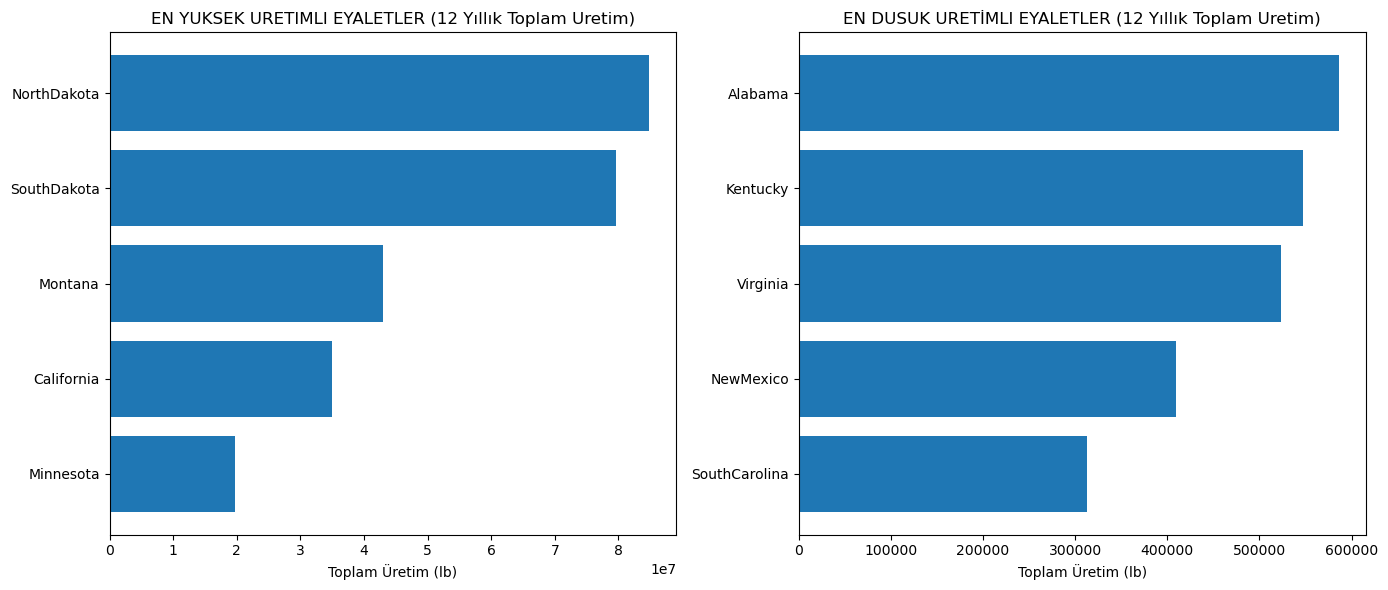

               - En yüksek toplam üretim: NorthDakota                                     - En düşük toplam üretim: Alabama


   --> Daha önce 'Kentucky (2011)' en düşük üretimi yapan 'YIL' olarak bulunmuştu.
   --> Ancak bu grafikte 'Alabama' en düşük 'TOPLAM' üretime sahiptir.



In [11]:
############################### EYALET URETIM PERFORMANSI #####################################################
# Bu kısımda 12 Yıllık süreçte toplamda kim ne kadar üretti ona bakacağız ve grafiğe dökeceğiz


# Eyaletleri 12 yıllık TOPLAM üretime göre sırala
eyalet_uretim = df.groupby('Eyalet')['Uretim'].sum().sort_values(ascending=False)

# en yüksek ve en düsük üretime sahip 5 il
top_5 = eyalet_uretim.head(5)
bottom_5 = eyalet_uretim.tail(5)

# Grafikler
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Grafik --> En yüksek üretim yapan eyaletler
ax1.barh(top_5.index, top_5.values)
ax1.set_title("EN YUKSEK URETIMLI EYALETLER (12 Yıllık Toplam Uretim)")
ax1.set_xlabel("Toplam Üretim (lb)")
ax1.invert_yaxis()

# 2. Grafik --> # En düşük üretim yapan eyaletler
ax2.barh(bottom_5.index, bottom_5.values)
ax2.set_title("EN DUSUK URETİMLI EYALETLER (12 Yıllık Toplam Uretim)")
ax2.set_xlabel("Toplam Üretim (lb)")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Grafikler hakkında yorumlar
# Renk kodlarını tanımlayalım (Okunabilirlik için)
YESIL_KALIN = "\033[1;92m"  # 1: Kalın, 92: Parlak Yeşil
KIRMIZI_KALIN = "\033[1;91m" # 1: Kalın, 91: Parlak Kırmızı
RESET = "\033[0m"            # Rengi ve stili sıfırla
# print("\n")
print(" "*15+f"{YESIL_KALIN}- En yüksek toplam üretim: {top_5.index[0]}{RESET}" + " "*37 
      + f"{KIRMIZI_KALIN}- En düşük toplam üretim: {bottom_5.index[0]}{RESET}")
print("\n")
print("   --> Daha önce 'Kentucky (2011)' en düşük üretimi yapan 'YIL' olarak bulunmuştu.")
print("   --> Ancak bu grafikte 'Alabama' en düşük 'TOPLAM' üretime sahiptir.\n")

In [ ]:
le7 = 10 üzeri 7'yi temsil etmektedir(milyon). 
Daha önce 'Kentucky (2011)' en düşük üretimi yapan 'YIL' olarak bulunmuştu.
bu grafikte tüm yıllara göre ortalama alınmıştır ve Alabama en düşük 'TOPLAM' üretime sahiptir.

In [13]:
########################### 2010-2021 DONEMSEL DEGISIM ANALIZI ##################################################
# BU kısımda ise bal üretimi sektöründe zaman içerisindeki değişimini ölçeceğiz.
# Üretim Fiyat ve Verim değişimlerini yüzdelik olarak inceliyeceğiz(Hesaplamalar eyalet ortalamalarına göre yapılmıştır).

# İlk ve son yıl ortalamaları
ilk_yil_verisi = df[df['Yil'] == df['Yil'].min()][['Uretim', 'Ortalama_Fiyat', 'Koloni_Verimi']].mean()
son_yil_verisi = df[df['Yil'] == df['Yil'].max()][['Uretim', 'Ortalama_Fiyat', 'Koloni_Verimi']].mean()

# Yüzdelik değişim hesapları --> ((Son - İlk) / İlk) * 100
uretim_degisim = ((son_yil_verisi['Uretim'] - ilk_yil_verisi['Uretim']) / ilk_yil_verisi['Uretim']) * 100
fiyat_degisim = ((son_yil_verisi['Ortalama_Fiyat'] - ilk_yil_verisi['Ortalama_Fiyat']) / ilk_yil_verisi['Ortalama_Fiyat']) * 100
verim_degisim = ((son_yil_verisi['Koloni_Verimi'] - ilk_yil_verisi['Koloni_Verimi']) / ilk_yil_verisi['Koloni_Verimi']) * 100

# print("-"*110)
print(f"\n2010 - 2021 ARASI PİYASA DEĞİŞİMİ")
# print("-"*110)

print(f"\n1. ÜRETİM DEĞİŞİMİ : %{uretim_degisim:.2f}")
if uretim_degisim < 0:
    print("   --> Zaman içerisinde üretimde azalma gözlemlenmiştir.")

print(f"\n2. VERİM DEĞİŞİMİ  : %{verim_degisim:.2f}")
print("   --> Koloni başına verim düşüş eğilimindedir.")

print(f"\n3. FİYAT DEĞİŞİMİ  : +%{fiyat_degisim:.2f}")
print("   --> Üretimdeki azalmaya paralel olarak fiyatlar artış göstermiştir.")

print("\n")


2010 - 2021 ARASI PİYASA DEĞİŞİMİ

1. ÜRETİM DEĞİŞİMİ : %-48.24
   --> Zaman içerisinde üretimde azalma gözlemlenmiştir.

2. VERİM DEĞİŞİMİ  : %-17.01
   --> Koloni başına verim düşüş eğilimindedir.

3. FİYAT DEĞİŞİMİ  : +%72.85
   --> Üretimdeki azalmaya paralel olarak fiyatlar artış göstermiştir.




In [ ]:
Yukarıdaki kısımda ise bal üretimi sektöründe zaman içerisindeki değişimini ölçeceğiz.
Üretim Fiyat ve Verim değişimlerini yüzdelik olarak inceliyeceğiz(Hesaplamalar eyalet ortalamalarına göre yapılmıştır).

In [15]:
########################### DAĞILIM ANALİZİ VE NORMALLİK TESTİ ###############################################
print("\n --> DAGILIM ANALİZİ ve NORMALLIK TESTI <-- \n")

# Toplam üretim eyalet büyüklüğüne bağlıdır.
# Koloni Verimi daha adil.
alpha = 0.05 # %95 güven düzeyi
# Skewness (Çarpıklık) ve Kurtosis
# 1. Temel Dağılım Ölçütleri
skew_val = df['Koloni_Verimi'].skew()
kurt_val = df['Koloni_Verimi'].kurt()

print(f"Çarpıklık (Skewness): {skew_val:.2f}")
print(f"Basıklık (Kurtosis):  {kurt_val:.2f}\n")

# Bu değerler verinin normal dağılıp dağılmadığı hakkında ipucu verir.
if skew_val > 1:
    print(f"   --> skewness değeri ({skew_val:.2f})>1 olduğu için sağa çarpıktır.")
    print("    Düşük verimli gözlemler çoktur. yüksek verimliler uç değer oluşturur.\n")
elif skew_val < -1:
    print("   --> Veri SOLA ÇARPIKTIR.")
else:
    print("   --> Veri yaklaşık simetrik yapıdadır.")

if kurt_val > 0:
    print(f"   --> kurtosis değeri ({kurt_val:.2f})>0 beklenmedik değerler fazladır.\n")
else:
    print("   --> Kurtosis negatif: Dağılım daha basıktır.")


# 3. HIPOTEZ KONTROLU
# Normallik Testi (Shapiro-Wilk)
# H0: Veri normal dağılıma sahiptir.
# H1: Veri normal dağılmamaktadır.
stat, p = shapiro(df['Koloni_Verimi'])
print(" H0: Veri normal dağılıma sahiptir. ")
print (" H1: Veri normal dağılmamaktadır. ")

print(f"\nShapiro-Wilk Testi: İstatistik={stat:.4f}, P-Değeri={p:.20f}")

if p > alpha: #sınır değerimiz 
    print(" SONUÇ: H0 reddedilemez → Veri normal dağılıma uygundur.")
else:
    print("     SONUÇ: H0 reddedilir → Veri normal dağılıma uygun değildir.")
    print(" --> Bu nedenle doğrusal olmayan modeller daha uygun olacaktır. ")


 --> DAGILIM ANALİZİ ve NORMALLIK TESTI <-- 

Çarpıklık (Skewness): 1.19
Basıklık (Kurtosis):  1.94

   --> skewness değeri (1.19)>1 olduğu için sağa çarpıktır.
    Düşük verimli gözlemler çoktur. yüksek verimliler uç değer oluşturur.

   --> kurtosis değeri (1.94)>0 beklenmedik değerler fazladır.

 H0: Veri normal dağılıma sahiptir. 
 H1: Veri normal dağılmamaktadır. 

Shapiro-Wilk Testi: İstatistik=0.9239, P-Değeri=0.00000000000000753572
     SONUÇ: H0 reddedilir → Veri normal dağılıma uygun değildir.
 --> Bu nedenle doğrusal olmayan modeller daha uygun olacaktır. 


In [ ]:
Bu bölümde, modelleme öncesinde verimizin yapısını anlamak için "Normallik Testi" (Shapiro-Wilk) uygulanmıştır.
Test için toplam üretim yerine, eyalet büyüklüğünden bağımsız olduğu için biyolojik verimliliği en iyi temsil eden
Koloni Verimi değişkeni seçilmiştir.
Bu analizdeki temel amacımız, verimizin yapısını anlamaktır.
İstatistiksel testlerde H0 Hipotezi, verinin "Normal Dağıldığını" varsayar.
Bizim yaptığımız test sonucunda elde ettiğimiz P-Değeri, 
kabul edilebilir sınır olan 0.05'ten (%95 güven düzeyi) çok daha küçük çıkmıştır.
Bunun anlamı şudur: Bu verinin normal dağılmıyor.

Eksik Değer Sayıları
Eyalet            0
Koloni_Sayisi     0
Koloni_Verimi     0
Uretim            0
Stoklar           0
Ortalama_Fiyat    0
Uretim_Degeri     0
Yil               0
dtype: int64


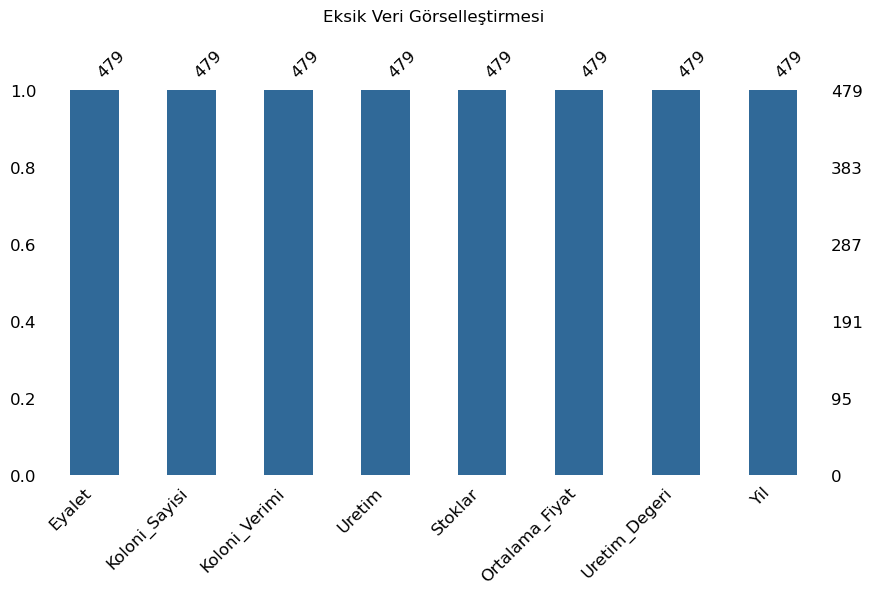

In [47]:
########################### EKSIK DEGER ANALIZI ###############################################
# Veri setinde eksik bir değer olmadığının grafiği aşağıda mevcuttur.
print("Eksik Değer Sayıları")
print(df.isnull().sum())

plt.figure(figsize=(8,5))
msno.bar(df, color="#306998", sort="ascending", figsize=(10,5), fontsize=12)
plt.title("Eksik Veri Görselleştirmesi\n")
plt.show()

In [ ]:
Veri bütünlüğünü göstermek için eksik değer (Null) kontrolü yapılmış ve görselleştirilmiştir.

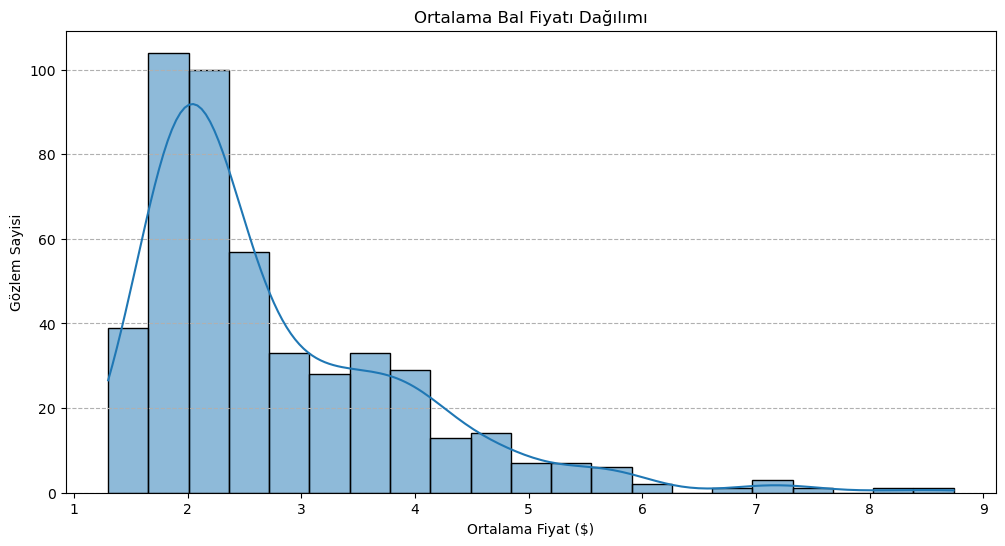

 --> Genel olarak fiyatlar 1.5$ ile 3$ arasında yogunlasmıstir.



In [17]:
########################### ORTALAMA FIYAT DAGILIMI GRAFIGI ###############################################

plt.figure(figsize=(12, 6))
sns.histplot(df['Ortalama_Fiyat'], kde=True)
plt.title("Ortalama Bal Fiyatı Dağılımı")
plt.xlabel("Ortalama Fiyat ($)")
plt.ylabel("Gözlem Sayisi")
plt.grid(axis='y', linestyle='--')
plt.show()
print(" --> Genel olarak fiyatlar 1.5$ ile 3$ arasında yogunlasmıstir.\n")

In [ ]:
Bal fiyatlarının genel dağılımını ve en sık görülen fiyat aralığı gösterilmiştir.
Genel olarak fiyatlar 1.5$ ile 3$ arasında yogunlasmıstir.

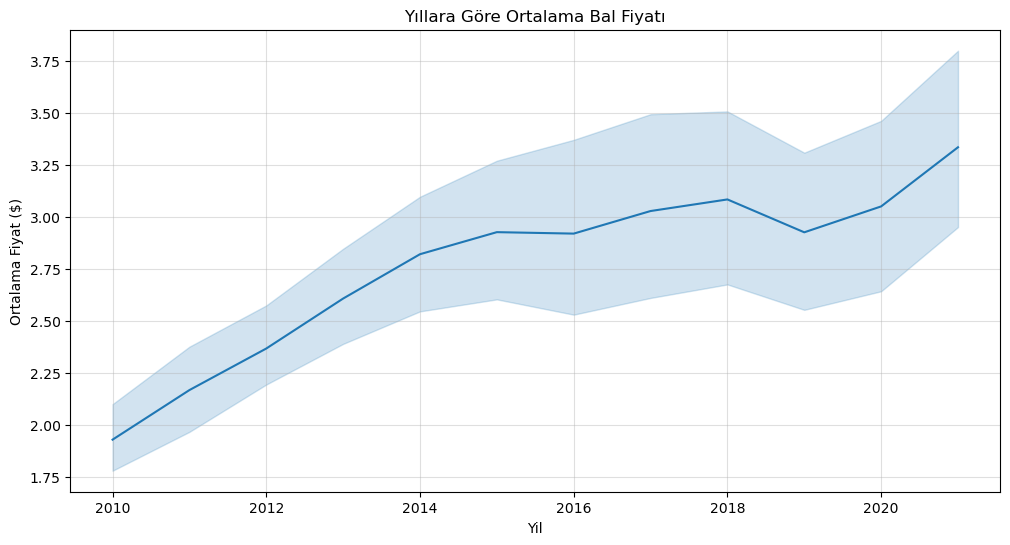


--> Zaman içinde bal fiyatlarının istikrarlı biçimde arttığı görülmektedir.
--> Önceki bloklarda tespit edilen üretim düşüşü ile artışın görselleştirilmesi.



In [53]:
########################### YILLARA GÖRE ORTALAMA BAL FİYATI ###############################################
# 2010–2021 arasında bal fiyatlarının zaman içindeki değişimi
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Yil', y='Ortalama_Fiyat', estimator='mean')
plt.title("Yıllara Göre Ortalama Bal Fiyatı")
plt.ylabel("Ortalama Fiyat ($)")
plt.grid(alpha=0.4)
plt.show()
print("\n--> Zaman içinde bal fiyatlarının istikrarlı biçimde arttığı görülmektedir.")
print("--> Önceki bloklarda tespit edilen üretim düşüşü ile artışın görselleştirilmesi.\n")

In [ ]:
Yıllara göre (2010-2021) ortalama bal fiyatı grafiği verilmiştir.

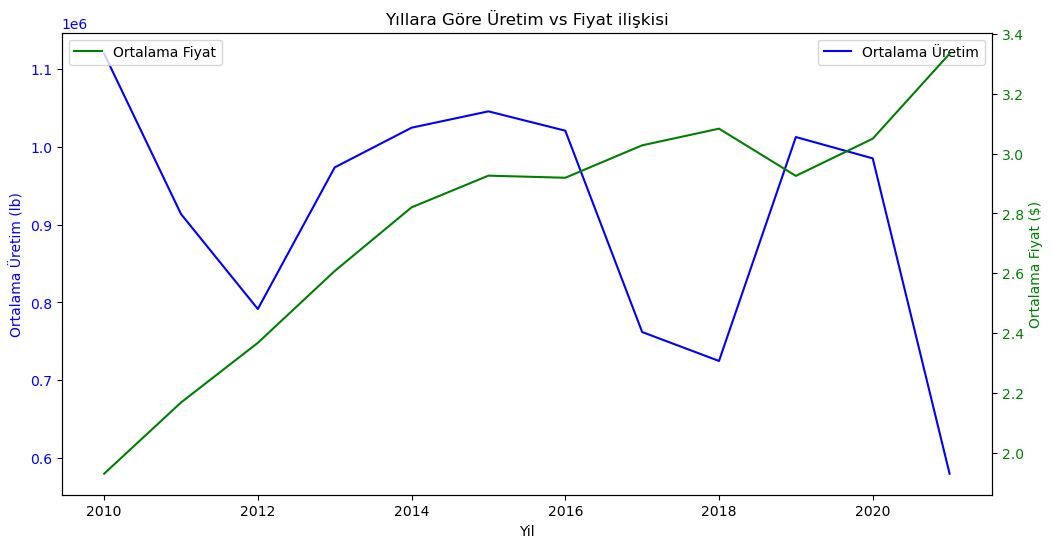

--> Üretim yıllar içinde azalırken, fiyatların arttığı görülmektedir.
--> Bu durum klasik arz–talep.


In [19]:
########################### YILLARA GÖRE FIYAT ARTISI  ###############################################
# Iste bu grafikte ise yukarıdaki fiyat artisinin gercek sebebini yani üretimin azalmasini goruyoruz.
# Yillara gore Uretim azaldikca fiyat'da yukselmistir (tahminimce)
plt.figure(figsize=(12,6))

# Sol Eksen: Üretim
ax1 = sns.lineplot(
    data=df, x='Yil', y='Uretim', estimator='mean',
    color='blue', label='Ortalama Üretim', errorbar=None)
ax1.set_ylabel('Ortalama Üretim (lb)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(False)

# Sağ Eksen: Fiyat
ax2 = ax1.twinx()
sns.lineplot(data=df, x='Yil', y='Ortalama_Fiyat', estimator='mean',
             color='green', label='Ortalama Fiyat', ax=ax2, errorbar=None)
ax2.set_ylabel('Ortalama Fiyat ($)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title("Yıllara Göre Üretim vs Fiyat ilişkisi")
plt.show()
print("--> Üretim yıllar içinde azalırken, fiyatların arttığı görülmektedir.")
print("--> Bu durum klasik arz–talep.")

In [ ]:
Yillara gore Uretim azaldikca fiyat'da yukselmistir (tahminimce) {ARZ-TALEP ILISKISI}
Mavi çizgi = Ortalama Fiyatı gösterirken
Yeşil Çizgi = Ortalama üretimi göstermektedir.

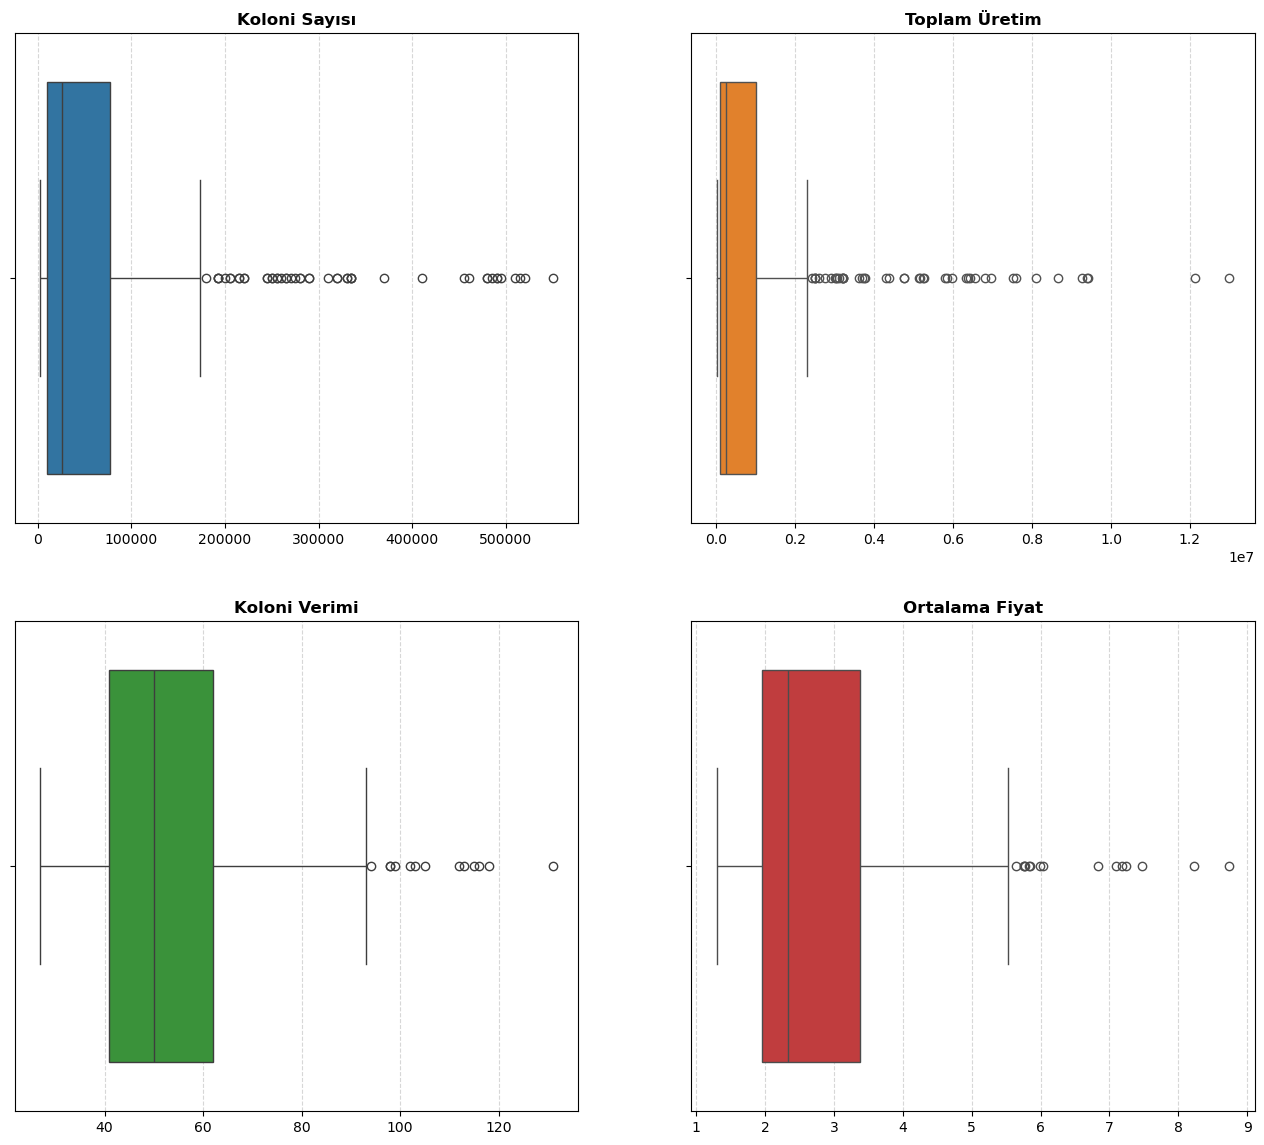


Koloni Sayısı
   (UÇ NOKTA: 178,750 üzerindeki değerler)
--------------------------------------------------------------------------------------------------------------
 NorthDakota     :  550,000
 California      :  410,000
 SouthDakota     :  290,000
 Florida         :  245,000

Toplam Üretim
   (UÇ NOKTA: 2,368,750 üzerindeki değerler)
--------------------------------------------------------------------------------------------------------------
 NorthDakota     :  12,995,000
 SouthDakota     :  12,127,000
 California      :  6,318,000
 Montana         :  5,802,000
 Minnesota       :  3,063,000

Koloni Verimi
   (UÇ NOKTA: 94 üzerindeki değerler)
--------------------------------------------------------------------------------------------------------------
 Hawaii          :  131 lb/kovan
 Mississippi     :  118 lb/kovan
 Louisiana       :  99 lb/kovan
 Montana         :  94 lb/kovan

Ortalama Fiyat
   (UÇ NOKTA: 6 üzerindeki değerler)
-------------------------------------------------

In [21]:
########################### GENEL AYKIRI DEĞER VE "DOMİNANT OYUNCULAR" RAPORU ##################################
# Amaç: İstatistiksel uç değerleri  tespit etmek


# 1. GRAFİK ÇİZİMİ (4'lü Panel)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
titles = ['Koloni Sayısı', 'Toplam Üretim', 
          'Koloni Verimi', 'Ortalama Fiyat']
cols = ['Koloni_Sayisi', 'Uretim', 'Koloni_Verimi', 'Ortalama_Fiyat']

for i, col in enumerate(cols):
    row, c = divmod(i, 2)
    sns.boxplot(data=df, x=col, ax=axes[row, c], color=colors[i])
    axes[row, c].set_title(f'{titles[i]}', fontweight='bold')
    axes[row, c].grid(axis='x', linestyle='--', alpha=0.5)
    axes[row, c].set_xlabel('')
    
plt.subplots_adjust(hspace=0.2)
plt.show()

for col, title in zip(cols, titles):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    ust_sinir = Q3 + 1.5 * IQR
    
    # Sınırı aşanları bul
    tum_aykirilar = df[df[col] > ust_sinir]
    
    print(f"\n{title}")
    print(f"   (UÇ NOKTA: {ust_sinir:,.0f} üzerindeki değerler)")
    print("-"*110)
    
    if not tum_aykirilar.empty:
        # Tekrar sayılarını bul
        tekrarlar = tum_aykirilar['Eyalet'].value_counts()
        # Eyaletleri tekilleştir (En yüksek değerlerini al)
        ozet_tablo = tum_aykirilar.sort_values(by=col, ascending=False).drop_duplicates(subset=['Eyalet']).head(5)
        
        for index, row in ozet_tablo.iterrows():
            eyalet = row['Eyalet']
            max_deger = row[col]
            yil_sayisi = tekrarlar[eyalet]
            
            if "Fiyat" in title:
                deger_str = f"${max_deger:.2f}"
            elif "Verim" in title:
                deger_str = f"{max_deger:,.0f} lb/kovan"
            else: # Üretim ve Koloni
                deger_str = f"{max_deger:,.0f}"
            print(f" {eyalet:<15} :  {deger_str}")          

In [ ]:
İstatistiksel uç değerlerin tespiti.


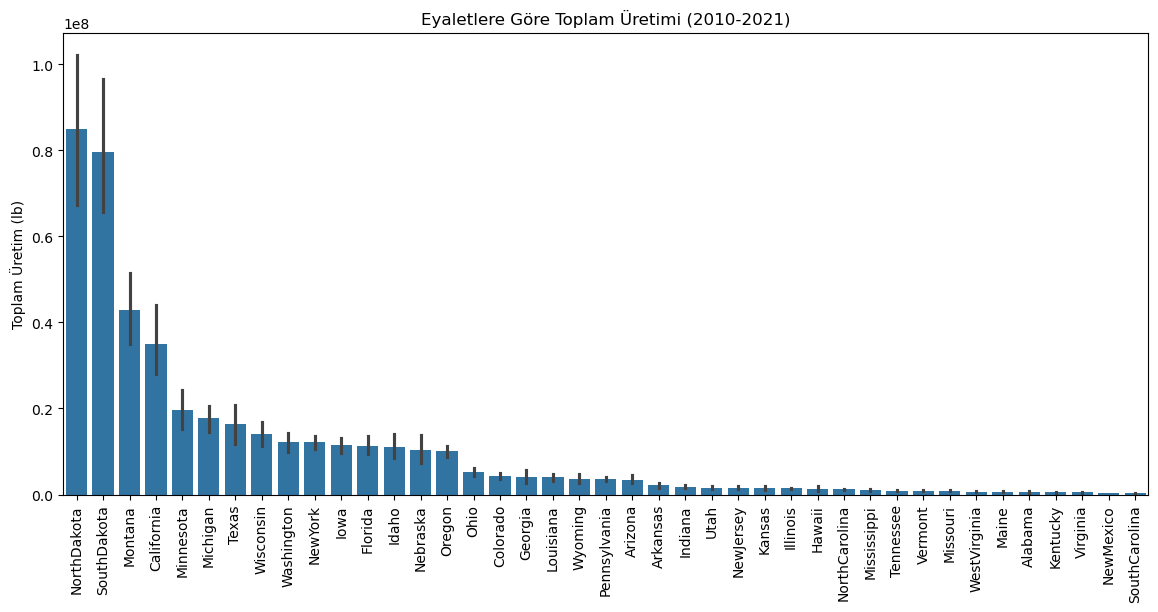

In [23]:
################################ EYALETLERE GÖRE TOPLAM BAL ÜRETİMİ ################################
# 2010–2021 döneminde bu grafikle hangi eyaletlerin sektörü domine ettiğini görebiliyoruz.
plt.figure(figsize=(14,6))
# Toplam üretime göre sıralama
siralama = df.groupby('Eyalet')['Uretim'].sum().sort_values(ascending=False).index
sns.barplot(data=df, x='Eyalet', y='Uretim', estimator='sum', order=siralama)

plt.xticks(rotation=90)
plt.title("Eyaletlere Göre Toplam Üretimi (2010-2021)")
plt.ylabel("Toplam Üretim (lb)")
plt.xlabel("")

plt.show()

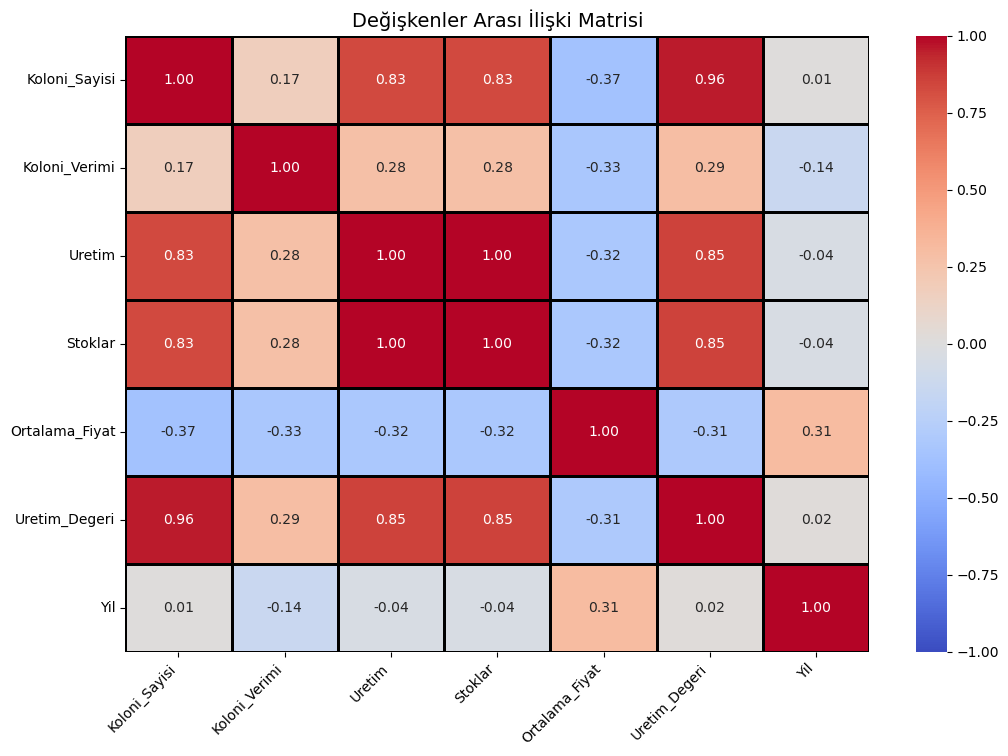


MATRIS YORUMU:
 
1. Güçlü Pozitif İlişkiler:
 1.1 --> 'Uretim' ve 'Stoklar': Beklendiği gibi, çok üreten eyaletler çok stok yapıyor.
 1.2 --> 'Uretim' ve 'Uretim_Degeri': Ne kadar çok bal, o kadar çok ciro.

2. KRİTİK NEGATİF (MAVİ ALANLAR):
 2.1 --> 'Ortalama_Fiyat' ile 'Koloni_Verimi' arasında belirgin MAVİ (Negatif) ilişki var.
          yani Verim düştükçe (bal azaldıkça), fiyatlar yükselmektedir.
=> Bu ilişki, projenin ana hipotezi olan 'Kıtlık = Pahalılık' görüşünü destekler.



In [524]:
################################ KORELASYON MATRİSİ ###############################################################
plt.figure(figsize=(12, 8))

# Korelasyonu hesapla ve çiz
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=1, 
            linecolor='black')

plt.title("Değişkenler Arası İlişki Matrisi", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

# --- GRAFİK YORUMU (SONUC ve RAPOR) ---
print("\nMATRIS YORUMU:\n ")
print("1. Güçlü Pozitif İlişkiler:")
print(" 1.1 --> 'Uretim' ve 'Stoklar': Beklendiği gibi, çok üreten eyaletler çok stok yapıyor.")
print(" 1.2 --> 'Uretim' ve 'Uretim_Degeri': Ne kadar çok bal, o kadar çok ciro.\n")
print("2. KRİTİK NEGATİF (MAVİ ALANLAR):")
print(" 2.1 --> 'Ortalama_Fiyat' ile 'Koloni_Verimi' arasında belirgin MAVİ (Negatif) ilişki var.")
print("          yani Verim düştükçe (bal azaldıkça), fiyatlar yükselmektedir.")
print("=> Bu ilişki, projenin ana hipotezi olan 'Kıtlık = Pahalılık' görüşünü destekler.\n")


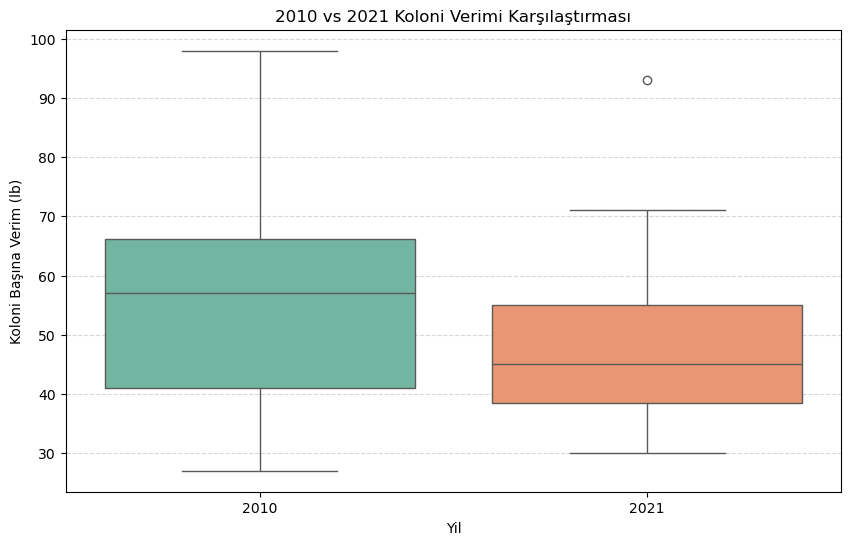


          HİPOTEZ TESTİ: 2010 ve 2021 Yılları Arasındaki Verim Farkı

HİPOTEZLER:
 -->H0 : 2010 ve 2021 yılları arasında koloni verimi açısından fark YOKTUR.
 -->H1 : 2010 ve 2021 yılları arasında koloni verimi açısından anlamlı fark VARDIR
--------------------------------------------------------------------------------------------------------------
T-İstatistiği: 2.9098
P-Değeri: 0.0048
--------------------------------------------------------------------------------------------------------------
 H0 REDDEDİLDİ (p < 0.05)
  SONUÇ: 2010-2021 arasındaki koloni verimi farkı Anlamlıdır.
  --> Bal verimindeki düşüş tesadüfi değildir.


In [25]:
################################ HİPOTEZ TESTİ (T-TESTİ) #########################################################
#EDA sürecinde gözlemlenen "Koloni Verimi düşüşü"nün istatistiksel olarak anlamlı olup olmadığına bakacağız.
#yani bu düşüşün rastgele mi yoksa gerçekten bir değişim mi olduğunu öğreneceğiz.

# İki yılın dağılımını yan yana gösteriyoruz
# farkı göstermek için
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['Yil'].isin([2010, 2021])], x='Yil', y='Koloni_Verimi', palette='Set2')
plt.title("2010 vs 2021 Koloni Verimi Karşılaştırması")
plt.ylabel("Koloni Başına Verim (lb)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Yıllara göre verimler
verim_2010 = df[df['Yil'] == 2010]['Koloni_Verimi']
verim_2021 = df[df['Yil'] == 2021]['Koloni_Verimi']

print("\n          HİPOTEZ TESTİ: 2010 ve 2021 Yılları Arasındaki Verim Farkı\n")
print("HİPOTEZLER:")
print(" -->H0 : 2010 ve 2021 yılları arasında koloni verimi açısından fark YOKTUR.")
print(" -->H1 : 2010 ve 2021 yılları arasında koloni verimi açısından anlamlı fark VARDIR")
print("-"*110)

# Welch T-Testi (varyansların eşit olduğunu varsayamadığımız için)
t_stat, p_val = stats.ttest_ind(verim_2010, verim_2021,equal_var=False)

print(f"T-İstatistiği: {t_stat:.4f}")
print(f"P-Değeri: {p_val:.4f}")
print("-"*110)
alpha = 0.05 # %95 güven düzeyi

if p_val < alpha:
    print(" H0 REDDEDİLDİ (p < 0.05)")
    print("  SONUÇ: 2010-2021 arasındaki koloni verimi farkı Anlamlıdır.")
    print("  --> Bal verimindeki düşüş tesadüfi değildir.")
else:
    print(" H0 REDDEDİLEMEDİ (p ≥ 0.05)")
    print(" \nSONUÇ: Anlamlı bir fark bulunamamıştır.")

In [ ]:
Yukarıdaki test ile amacımız gözlemlenen verim düşüşünün istatistiksel olarak anlamlı olup olmadığını test etmek.

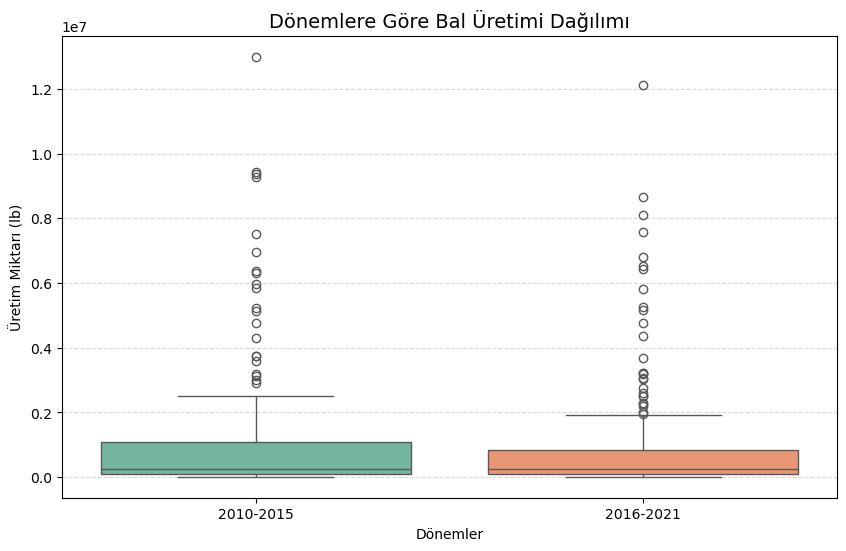


-->2016–2021 döneminde üretim dağılımının aşağı kaydığı gözlemlenmektedir.

--------------------------------------------------------------------------------------------------------------

1. SPEARMAN KORELASYON TESTİ
Katsayı: -0.524 | P-Değeri: 0.00000000000000000000000000000000004
SONUÇ: Fiyat ile üretim arasında istatistiksel olarak ANLAMLI bir ilişki vardır.
Yorum: Üretim azaldıkça fiyatların artması beklenen bir sonuçtur.




In [27]:
################################ ÜRETİM - FİYAT İLİŞKİSİ VE DÖNEMSEL FARK ANALİZİ #########################################################
#Üretim ile fiyat arasında istatistiksel ilişki olup olmadığını kontrol edeceğiz.
# Buradaki ana sorumuz 2010-2015 ile 2016-2021 dönemleri arasında üretim seviyesi değişmiş mi?
# Veri normal dağılmadığı için parametrik olmayan testler kullanılmıştır.

alpha = 0.05 # %95 güven düzeyi
df['Donem_Etiketi'] = df['Yil'].apply(lambda x: '2010-2015' if x <= 2015 else '2016-2021')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Donem_Etiketi', y='Uretim', data=df, palette='Set2')
plt.title('Dönemlere Göre Bal Üretimi Dağılımı', fontsize=14)
plt.xlabel('Dönemler')
plt.ylabel('Üretim Miktarı (lb)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
print("\n-->2016–2021 döneminde üretim dağılımının aşağı kaydığı gözlemlenmektedir.\n")

# Spearman Korelasyon Testi (Fiyat – Üretim İlişkisi)
corr, p_value = stats.spearmanr(df['Ortalama_Fiyat'], df['Uretim'])

print("-"*110)
print("\n1. SPEARMAN KORELASYON TESTİ")
print(f"Katsayı: {corr:.3f} | P-Değeri: {p_value:.35f}")
if p_value < alpha:
    print("SONUÇ: Fiyat ile üretim arasında istatistiksel olarak ANLAMLI bir ilişki vardır.")
    print("Yorum: Üretim azaldıkça fiyatların artması beklenen bir sonuçtur.")
else:
    print("SONUÇ: İstatistiksel olarak anlamlı bir ilişki bulunamamıştır.")
print("\n")

In [ ]:
1. Üretim ile Fiyat arasındaki ilişkiyi test etmek.
2. Sektörün 2015 öncesi ve sonrası performansını kıyaslayarak yapısal bir kırılma olup olmadığını bulmak.
Buradaki ana sorumuz 2010-2015 ile 2016-2021 dönemleri arasında üretim seviyesi değişmiş mi?
Önceki aşamalarda yapılan normallik testlerinde (Shapiro-Wilk), veri setimizin normal dağılıma uymadığı tespit edilmiştir.
Bu nedenle, parametrik olan "Pearson Korelasyonu" yerine veri dağılımından bağımsız çalışan
ve doğrusal olmayan ilişkileri de yakalayabilen "Spearman Sıra Korelasyonu" testi tercih edilmiştir.
Yapılan test sonucunda P-Değeri < 0.05 (Anlamlılık düzeyi) çıkmıştır.
Bu sonuç, üretim miktarı ile ortalama fiyat arasında istatistiksel olarak anlamlı bir ilişki olduğunu kanıtlar.

In [29]:
################################ MAKİNE ÖĞRENMESİNE GEÇİŞ #########################################################
baslik = "MAKİNE ÖĞRENMESİ İLE TAHMİN MODELLEMESİ"
print("-" * 100)
print("-" * 100)
print(baslik.center(100))
print("-" * 100)
print("-" * 100)
print("""
Bu noktaya kadar gerçekleştirilen analizlerde veri seti detaylı şekilde incelenmiştir.
Eksik veri yapısı kontrol edilmiş, üretim–fiyat–verim ilişkileri gibi bir çok durum
görselleştirilmiş ve istatistiksel testlerle desteklenmiştir.

--> Bal üretiminin yıllar içinde anlamlı şekilde azaldığı,
--> Koloni veriminin düştüğü,
--> Buna karşılık ortalama bal fiyatlarının arttığı,
--> Bu değişimlerin istatistiksel olarak anlamlı olduğu tespit edilmiştir.

Bu aşamadan sonra amaç, geçmiş yıllara ait bu değişkenleri kullanarak
bal üretimini tahmin edebilecek makine öğrenmesi modelleri oluşturmaktır.
""")

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
                              MAKİNE ÖĞRENMESİ İLE TAHMİN MODELLEMESİ                               
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

Bu noktaya kadar gerçekleştirilen analizlerde veri seti detaylı şekilde incelenmiştir.
Eksik veri yapısı kontrol edilmiş, üretim–fiyat–verim ilişkileri gibi bir çok durum
görselleştirilmiş ve istatistiksel testlerle desteklenmiştir.

--> Bal üretiminin yıllar içinde anlamlı şekilde azaldığı,
--> Koloni veriminin düştüğü,
--> Buna karşılık ortalama bal fiyatlarının arttığı,
--> Bu değişimlerin istatistiksel olarak anlamlı olduğu tespit edilmiştir.

Bu aşamadan sonra amaç, geçmiş yıllara ait

In [102]:
############################# PROBLEM TANIMI (ONEMLI KISIM) ##################################################
print(" Bu çalışmada amaç, bal üretim miktarını (Uretim) tahmin etmektir.\n ")

print (" Hedef değişken:")
print (" Uretim --> sayısal ve sürekli bir değişkendir. ")
print (" Belirli sınıflara AYRILMAMIŞTIR.\n ")

print (" Bu nedenle problem: ")
print (" Sınıflandırma DEĞİL ")
print (" Regresyon problemidir.\n  ")

print (" Modelin amacı: ")
print (" Koloni sayısı, fiyat, yıl ve eyalet bilgilerine bakarak ")
print (" üretim miktarını sayısal olarak tahmin etmek olacaktır.\n ")


print ("\n  Neden üretimi tahmin ediyoruz? ")
print ("  Fiyat, veri setinde yer almayan bir çok ekonomik faktörlere bağlıdır. ")
print ("  Üretim ise koloni sayısı ve verim gibi doğrudan gözlemlenen değişkenlerle açıklanabilir. ")

 Bu çalışmada amaç, bal üretim miktarını (Uretim) tahmin etmektir.
 
 Hedef değişken:
 Uretim --> sayısal ve sürekli (continuous) bir değişkendir. 
 Belirli sınıflara AYRILMAMIŞTIR.
 
 Bu nedenle problem: 
 Sınıflandırma DEĞİL 
 Regresyon problemidir.
  
 Modelin amacı: 
 Koloni sayısı, fiyat, yıl ve eyalet bilgilerine bakarak 
 üretim miktarını sayısal olarak tahmin etmek olacaktır.
 

  Neden üretimi tahmin ediyoruz? 
  Fiyat, veri setinde yer almayan bir çok ekonomik faktörlere bağlıdır. 
  Üretim ise koloni sayısı ve verim gibi doğrudan gözlemlenen değişkenlerle açıklanabilir. 


In [31]:
################################ VERİ HAZIRLIĞI ve ÖN İŞLEME #########################################################

# Buradaki amacımız makine öğrenmesi modellerine uygun bir veri yapısı oluşturmak
# Data Leakage'i önlemek için bazı önlemler alacağız ve ek olarak Kategorik ve sayısal değişkenleri doğru şekilde dönüştüreceğiz.
# Koloni Verimini çıkarıyoruz çünkü (Sayı * Verim = Üretim). Bu bir türetilmiş değişkendir.

X = df.drop(columns=[
    'Uretim',          # Hedef değişken
    'Uretim_Degeri',   # Üretimle doğrudan ilişkili
    'Stoklar',         # Üretimden türeyen bilgi
    'Koloni_Verimi'    # Veri sızıntısı riski
])
y = df['Uretim']

# Eğitim ve Test Bölme
# Verinin %80'i eğitim, %20'si test için ayrıldı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# random_state sabitlenerek tekrar üretilebilirlik sağlandı

# Ön İşleme Pipeline (Standardizasyon + One-Hot Encoding)
# Sadece elimizde tahmin anında olabilecek verileri kullanıyoruz
# Sayısal Değişkenler:
numeric_features = ['Koloni_Sayisi', 'Ortalama_Fiyat', 'Yil'] 
# Kategorik Değişken:
categorical_features = ['Eyalet']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("\nVeri seti bölündü.")
print(f"Eğitim Seti: {X_train.shape}")
print(f"Test Seti:   {X_test.shape}\n")


Veri seti bölündü.
Eğitim Seti: (383, 5)
Test Seti:   (96, 5)



In [ ]:
Buradaki amacımız makine öğrenmesi modellerine uygun bir veri yapısı oluşturmak
Data Leakage'i önlemek için bazı önlemler alacağız ve ek olarak Kategorik ve sayısal değişkenleri doğru şekilde dönüştüreceğiz.
Koloni Verimini çıkarıyoruz çünkü (Sayı * Verim = Üretim). Bu bir türetilmiş değişkendir.
Verinin %80'i eğitim, %20'si test için ayrıldı
"Eyalet" sütunu metin halindedir Her eyalet ismi ayrı bir sütuna dönüştürülmüştür.
Eğer satırdaki veri o eyalete aitse 1, değilse 0 değeri atanır.
Koloni_Sayısı (yüz binler) ve Ortalama_Fiyat (birler basamağı) çok farklı ölçeklerdedir.
Model, büyük sayıları daha önemli sanabilir.
Tüm sayısal veriler, ortalaması 0 ve standart sapması 1 olacak şekilde yeniden ölçeklendirilmiştir.
her değişkenin modele eşit ağırlıkta girmesi sağlanmıştır.

In [22]:
################################ MODEL EĞİTİMİ ve KARŞILAŞTIRMA #########################################################
# Burada ise farklı regresyon algoritmalarını veri setimiz üzerinde karşılaştıracağız ve bir çok modelin performansını
# gözlemleyeceğiz. Cross-validation ortalama R² skoruna göre en iyi modeli seçeceğiz.

models = {
    # Lineer Modeller
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    
    # Doğrusal Olmayanlar
    # Windows ortamında CPU kaynaklı hataları önlemek için n_jobs=1 kullandım
    'KNN': KNeighborsRegressor(n_jobs=1),
    'SVR': SVR(),
    'CART': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=1)
}


# Model Eğitimi ve Değerlendirme
trained_models = {}
results= []
print("\n")
print ("MODEL BAŞARI SONUÇLARI \n")
for name, model in models.items():

    reg = TransformedTargetRegressor(
        regressor=Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )
    
     # CROSS-VALIDATION
    cv_scores = cross_val_score(
        reg,
        X_train,
        y_train,
        cv=5,
        scoring='r2'
    )

    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    # EĞİT
    reg.fit(X_train, y_train)
    # TEST ET
    y_pred = reg.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'R2': r2,
        'CV_R2_Mean': cv_mean,
        'CV_R2_Std': cv_std
    })
    
    trained_models[name] = reg
    print(f"{name.ljust(20)} -> CV R2: {cv_mean:.4f} ± {cv_std:.4f} | Test R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values(
    by='CV_R2_Mean',
    ascending=False
)

# İndeks düzenlemesi
results_df = results_df.reset_index(drop=True)
results_df.index = results_df.index + 1

print("\n" + "-"*110)
print("MODEL BAŞARI SIRALAMASI:")
print("\n" + "-"*110)
print(results_df)



MODEL BAŞARI SONUÇLARI 

Linear Regression    -> CV R2: 0.7951 ± 0.1435 | Test R2: 0.7152
Ridge                -> CV R2: 0.6927 ± 0.3280 | Test R2: 0.6209
Lasso                -> CV R2: -0.0882 ± 0.0320 | Test R2: -0.0664
ElasticNet           -> CV R2: 0.1208 ± 0.0991 | Test R2: 0.0744
KNN                  -> CV R2: 0.8103 ± 0.0608 | Test R2: 0.7522
SVR                  -> CV R2: 0.7775 ± 0.1434 | Test R2: 0.8146
CART                 -> CV R2: 0.6968 ± 0.0525 | Test R2: 0.2513
Random Forest        -> CV R2: 0.8366 ± 0.0574 | Test R2: 0.7693
Gradient Boosting    -> CV R2: 0.8100 ± 0.0618 | Test R2: 0.8650
XGBoost              -> CV R2: 0.8028 ± 0.0577 | Test R2: 0.7870
LightGBM             -> CV R2: 0.7106 ± 0.1170 | Test R2: 0.7706

--------------------------------------------------------------------------------------------------------------
MODEL BAŞARI SIRALAMASI:

--------------------------------------------------------------------------------------------------------------
       

In [ ]:
Hedef değişkende (Üretim) yüksek varyans ve uç değerlerin etkisini azaltmak amacıyla logaritmik dönüşüm uygulanmıştır.
Burada ise farklı regresyon algoritmalarını veri setimiz üzerinde karşılaştıracağız ve bir çok modelin performansını gözlemiyoruz.
R^2 Bağımsız değişkenlerin (Koloni Sayısı, Eyalet, Yıl vb.), hedef değişkendeki (Üretim) değişimi ne kadar açıklayabildiğini gösteren orandır.
1'e ne kadar yakınsa model o kadar başarılıdır.
Girdilerimiz --> Koloni Sayisi , Eyalet , Ortalama Fiyat , Yıl
Çıkıtımız ise --> Üretim

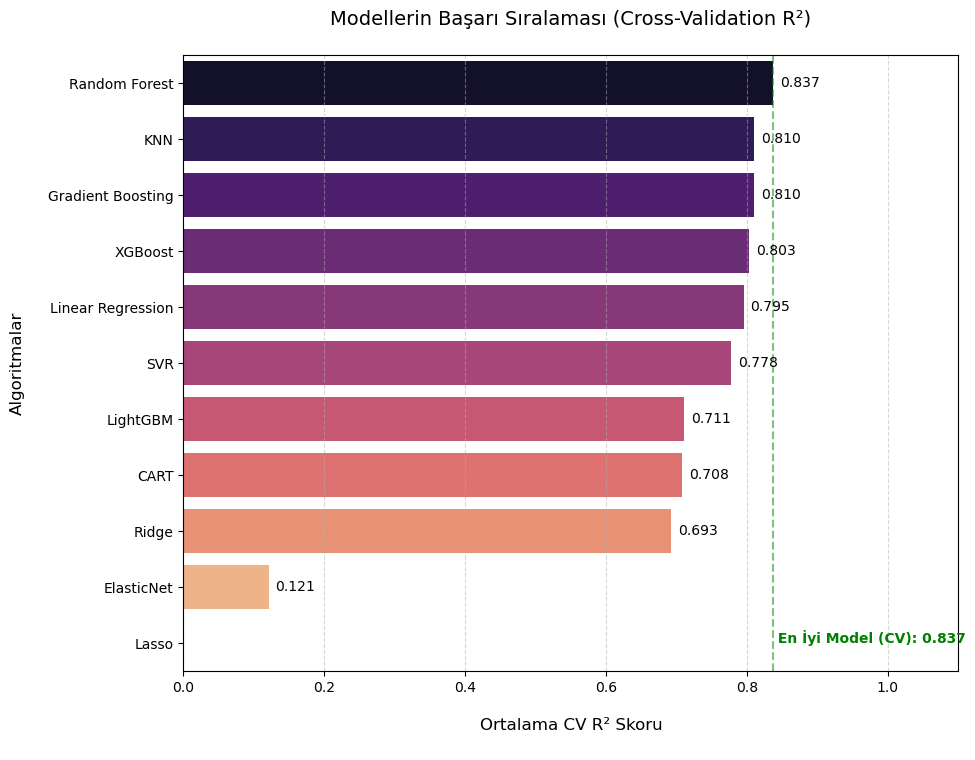

In [83]:
################################ MODEL BAŞARI GRAFİĞİ (CROSS-VALIDATION) ################################
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=results_df,
    x='CV_R2_Mean',
    y='Model',
    order=results_df['Model'],
    palette='magma'
)

plt.title("Modellerin Başarı Sıralaması (Cross-Validation R²)\n", fontsize=14)
plt.xlabel("\nOrtalama CV R² Skoru\n", fontsize=12)
plt.ylabel("Algoritmalar\n", fontsize=12)

plt.xlim(0, 1.1)

best_score = results_df.iloc[0]['CV_R2_Mean']
plt.axvline(best_score, color='green', linestyle='--', alpha=0.5)
plt.text(best_score, 10, f' En İyi Model (CV): {best_score:.3f}', 
         color='green', fontweight='bold')

for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=5, fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
Burada Modellerin başarı sıralaması grafik olarak gösterilmiştir.

In [ ]:
X Ekseni (Gerçek): Eyaletlerin gerçek bal üretim miktarları.
Y Ekseni ise Tahmin yani yapay zeka modelinin tahmin ettiği değerlerdir.

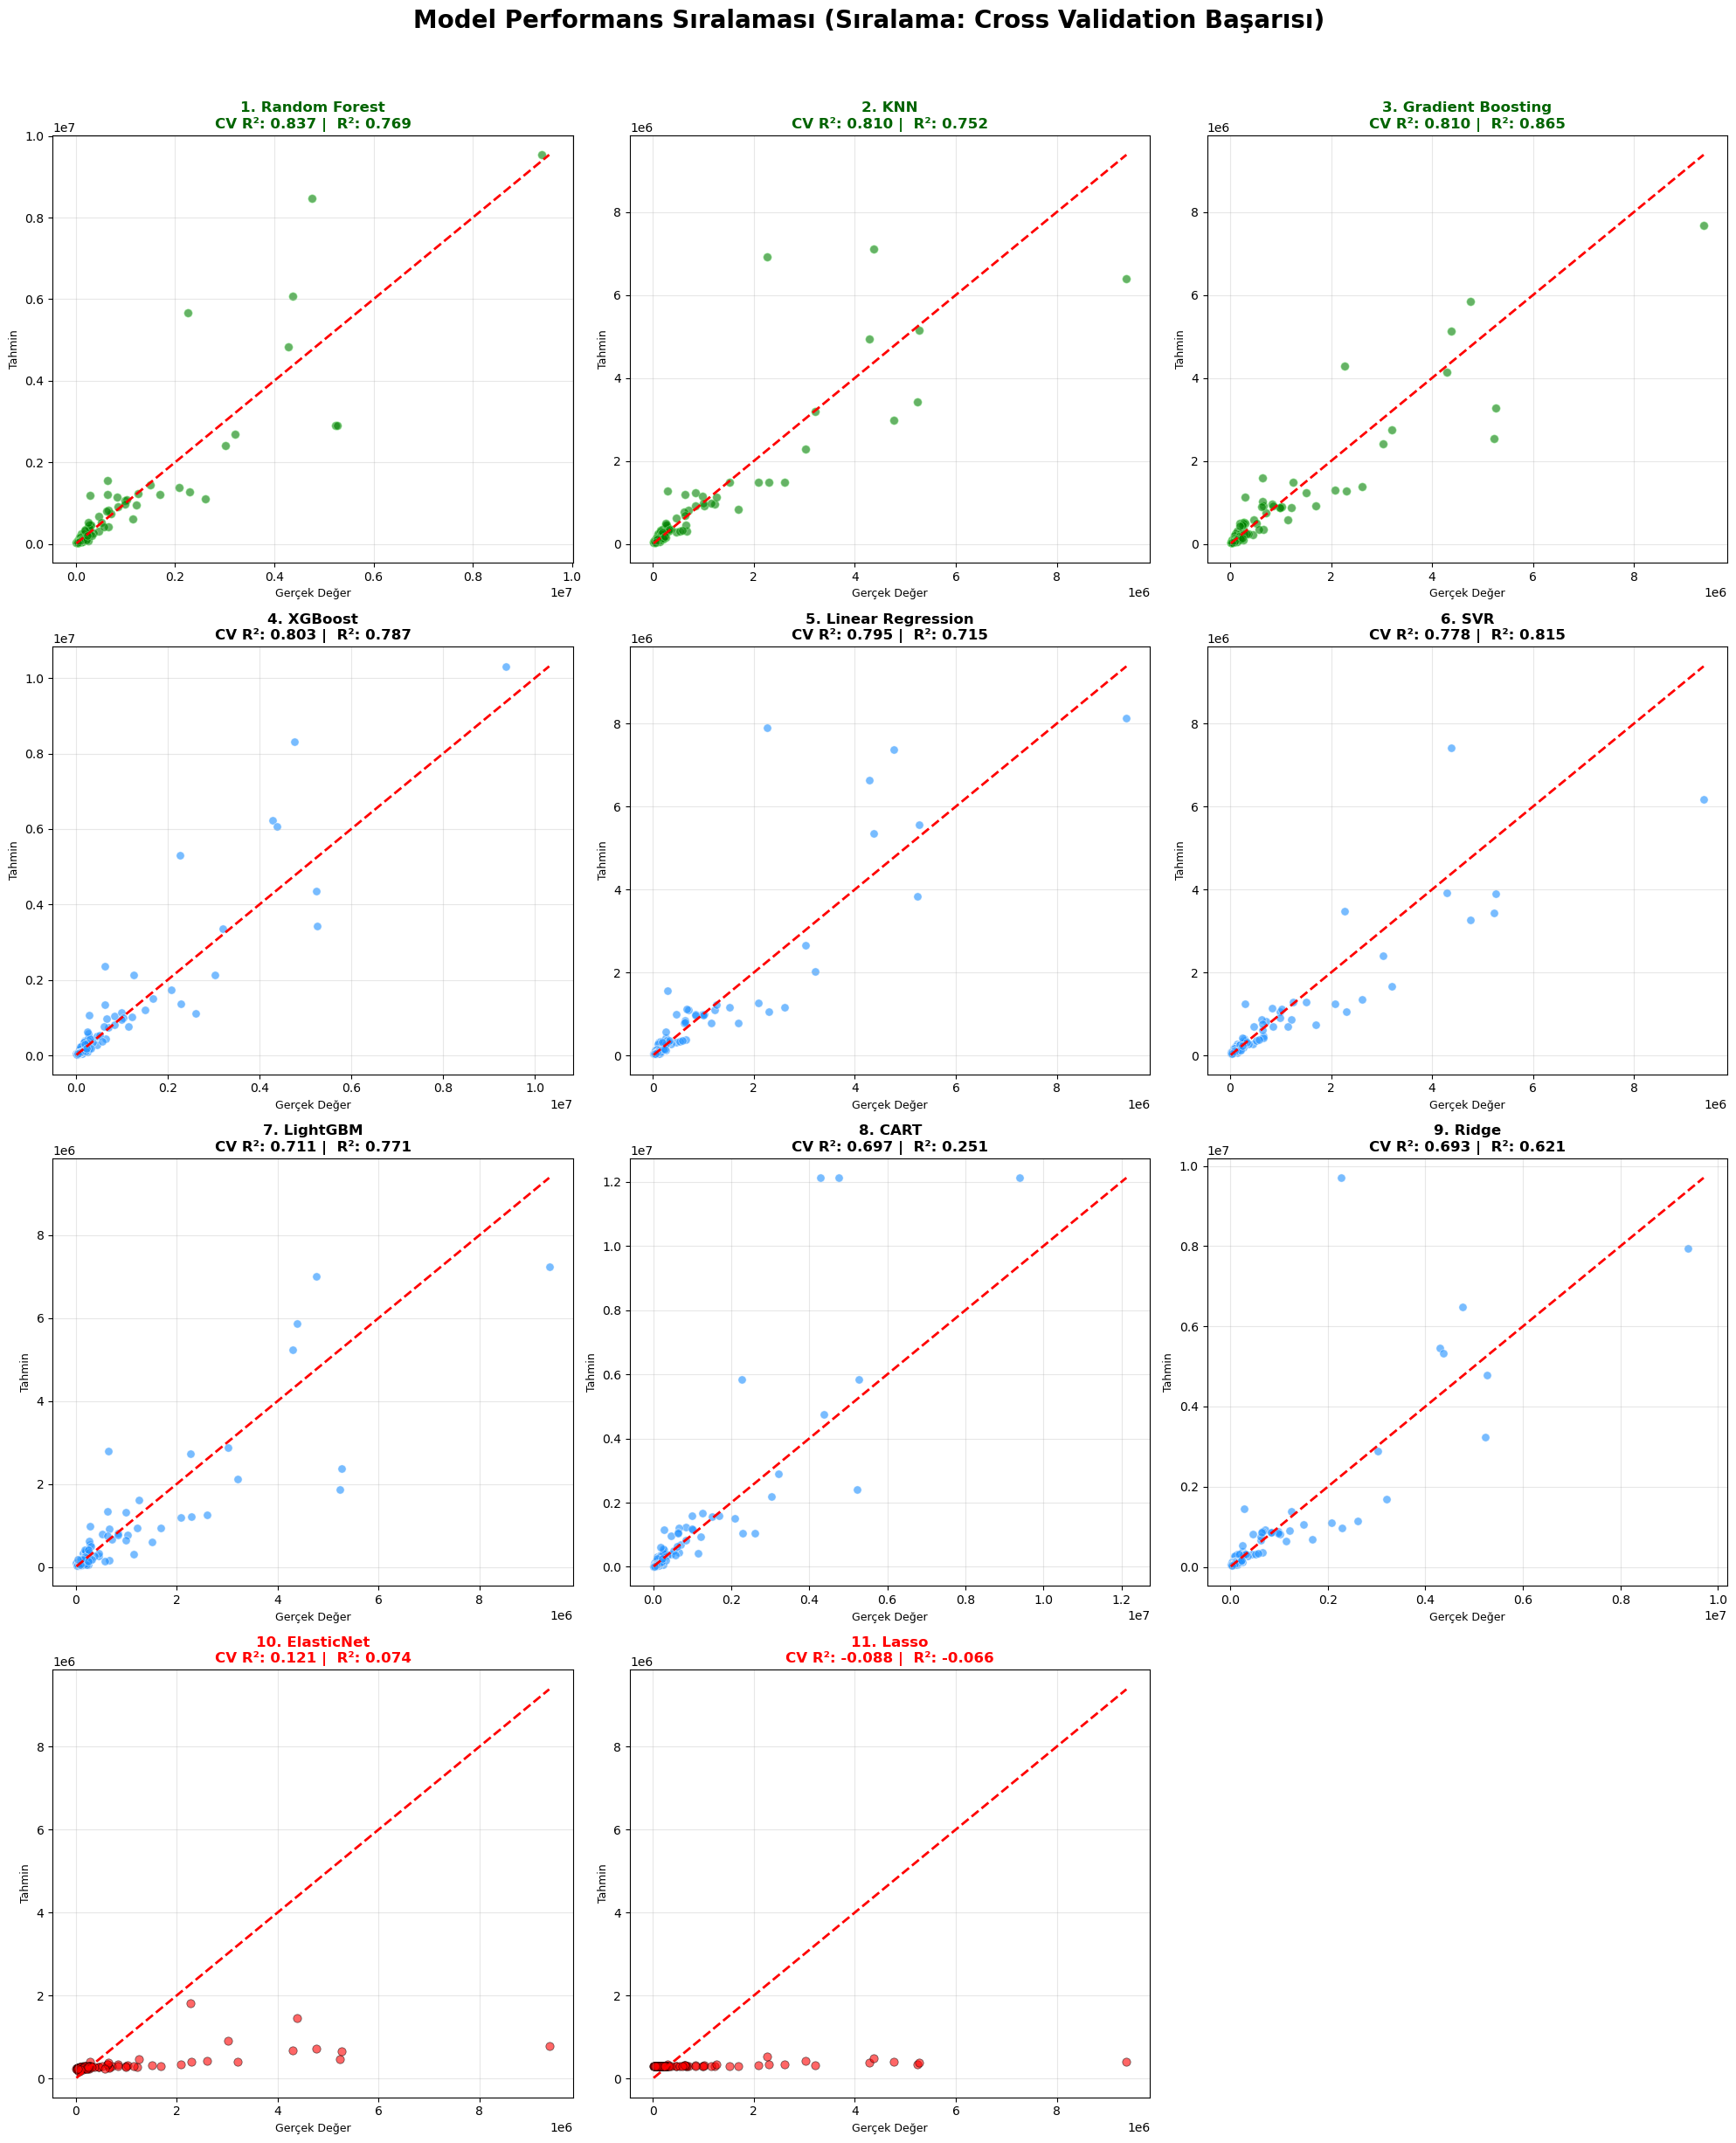

In [38]:

sorted_models = (
    results_df
    .sort_values(by='CV_R2_Mean', ascending=False)['Model']
    .tolist()
)

n_models = len(sorted_models)
n_cols = 3 
n_rows = math.ceil(n_models / n_cols)

plt.figure(figsize=(20, 24))
plt.suptitle("Model Performans Sıralaması (Sıralama: Cross Validation Başarısı)", 
             fontsize=20, fontweight='bold', y=1.02)

for i, model_name in enumerate(sorted_models):
    plt.subplot(n_rows, n_cols, i+1)
    
    # DAHA ÖNCE EĞİTİLMİŞ MODELİ AL
    model = trained_models[model_name]
    
    y_pred = model.predict(X_test)
    
    # Skorları al
    test_r2 = r2_score(y_test, y_pred)
    cv_r2 = results_df[results_df['Model'] == model_name]['CV_R2_Mean'].values[0]
    
    # Görselleştirme Renkleri 
    if i < 3:
        color = 'green' # İlk 3 model Yeşil 
        edge_color = 'lightgreen'
        title_color = 'darkgreen'
    elif cv_r2 < 0.2: 
        color = 'red'   
        edge_color = 'black'
        title_color = 'red'
    else:
        color = 'dodgerblue' # Orta seviye
        edge_color = 'white'
        title_color = 'black'

    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color=color, s=45, edgecolor=edge_color)
    
    # Red line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    # Başlıklar
    plt.title(f"{i+1}. {model_name}\nCV R²: {cv_r2:.3f} |  R²: {test_r2:.3f}", 
              fontsize=12, fontweight='bold', color=title_color)
    plt.xlabel("Gerçek Değer", fontsize=9)
    plt.ylabel("Tahmin", fontsize=9)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

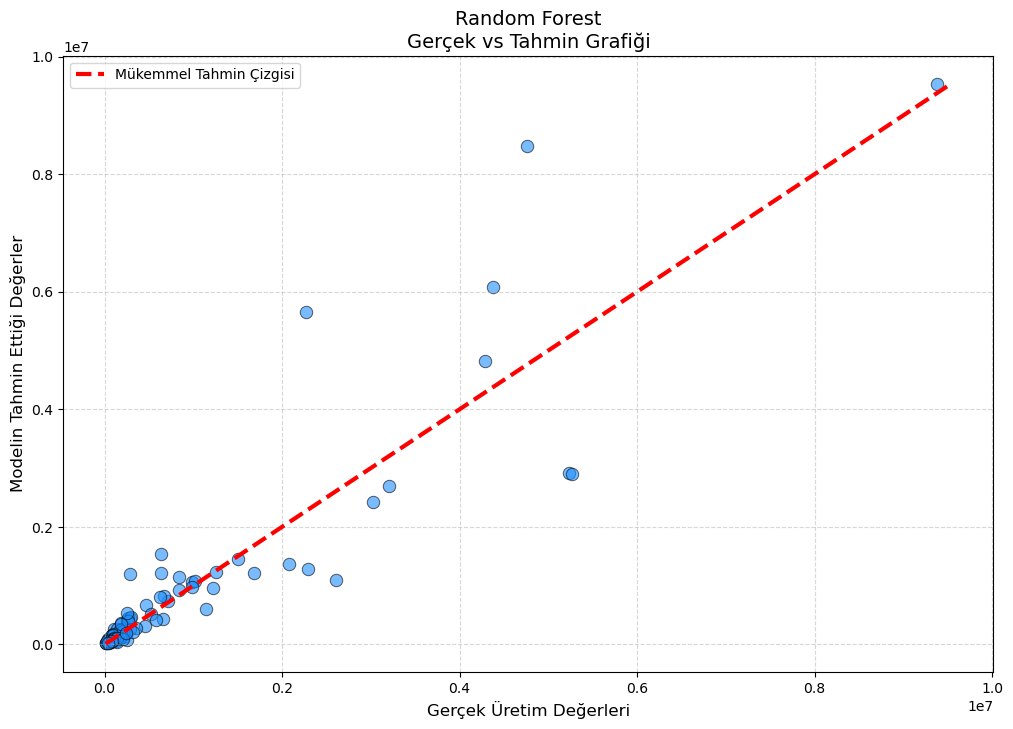

In [19]:
################################ KAZANAN MODEL #########################################################

# En iyi modeli otomatik seç
best_model_name = results_df.iloc[0]['Model']
best_model_score = results_df.iloc[0]['R2']


# Modeli tekrar kurulumu ve eğitim
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 8))

# Noktalar
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, color='dodgerblue', edgecolor='k', s=80)

# red line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=3, label='Mükemmel Tahmin Çizgisi')

# Başlıklar
plt.title(f'{best_model_name}\nGerçek vs Tahmin Grafiği', fontsize=14)
plt.xlabel('Gerçek Üretim Değerleri', fontsize=12)
plt.ylabel('Modelin Tahmin Ettiği Değerler', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
Yapılan kapsamlı testler ve karşılaştırmalar sonucunda,
veri setimizdeki karmaşık yapıyı en iyi çözümleyen algoritmanın Random Forest olduğu görülmüştür.

In [21]:
################################ İLK 3 MODELLE TAHMİN ################################

top3_models = results_df.head(3)['Model'].values

# Rastgele 10 örnek
ornek_lem = X_test.sample(10, random_state=42)
gercek_degerler = y_test.loc[ornek_lem.index]

for model_name in top3_models:

    model = trained_models[model_name]   

    tahminler = model.predict(ornek_lem)

    tablo = pd.DataFrame({
        'Yıl': ornek_lem['Yil'],
        'Eyalet': ornek_lem['Eyalet'],
        'GERÇEK (lb)': gercek_degerler,
        'TAHMİN (lb)': tahminler
    })

    tablo['Hata (%)'] = (
        abs(tablo['GERÇEK (lb)'] - tablo['TAHMİN (lb)']) /
        tablo['GERÇEK (lb)']
    ) * 100

    pd.options.display.float_format = '{:,.0f}'.format

    print("\n" + "=" * 110)
    print(f" {model_name} – ÖRNEK TAHMİNLER")
    print("=" * 110)
    print(tablo.to_string(formatters={'Hata (%)': '{:,.2f}%'.format}))



 Random Forest – ÖRNEK TAHMİNLER
      Yıl    Eyalet  GERÇEK (lb)  TAHMİN (lb) Hata (%)
19   2010  Missouri        92000       80,152   12.88%
15   2010     Maine        33000       53,483   62.07%
101  2012  Nebraska      1146000      603,477   47.34%
42   2011  Arkansas       239000      198,557   16.92%
90   2012   Indiana       203000      125,388   38.23%
371  2019    Kansas       171000      102,373   40.13%
422  2020   NewYork       844000      921,276    9.16%
400  2020   Arizona       360000      278,820   22.55%
93   2012  Kentucky        41000       58,509   42.71%
238  2015   Wyoming       146000      258,197   76.85%

 KNN – ÖRNEK TAHMİNLER
      Yıl    Eyalet  GERÇEK (lb)  TAHMİN (lb) Hata (%)
19   2010  Missouri        92000       87,895    4.46%
15   2010     Maine        33000       59,340   79.82%
101  2012  Nebraska      1146000      976,932   14.75%
42   2011  Arkansas       239000      175,856   26.42%
90   2012   Indiana       203000      128,132   36.88%
371  20

In [ ]:
Bu bölümde, cv_R² skoruna göre en başarılı bulunan ilk üç regresyon modelinin,
daha önce hiç görmediği test verileri üzerindeki tahmin performansları karşılaştırmalı olarak incelenmiştir.
Modeller yalnızca bir kez eğitilmiş ve Tahmin aşamasında yeniden eğitim yapılmamıştır.
Rastgele seçilen 10 test örneği üzerinden gerçek–tahmin karşılaştırması yapılmıştır.

In [ ]:
Eyaletleri üretim ve verime göre "Zayıf", "Orta", "Güçlü" gibi sınıflara ayırmak istiyoruz.

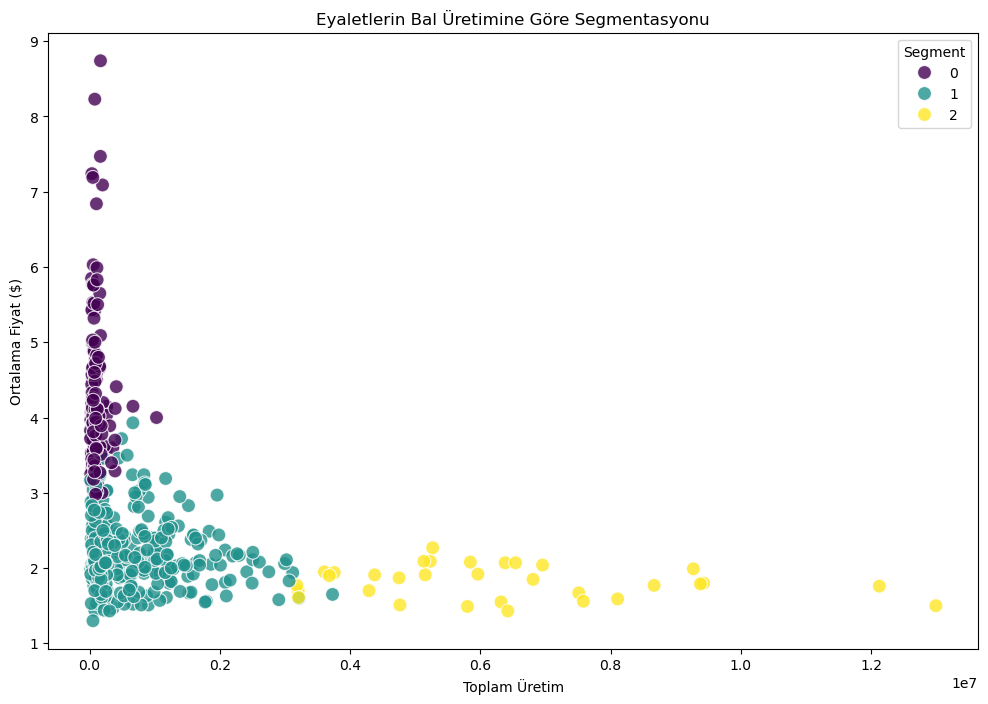


>>> KÜME PROFİLLERİ (Segmentlerin Karakteristiği):

--------------------------------------------------------------------------------------------------------------
               Uretim  Koloni_Verimi  Ortalama_Fiyat
Segment                                             
0        1.144504e+05      44.435115        4.336412
1        6.978354e+05      54.765823        2.207152
2        6.303406e+06      73.125000        1.817187

--------------------------------------------------------------------------------------------------------------
KÜME 0: Düşük/Orta Üretim, Pahalı Bal, Düşük Verim.
KÜME 1: Düşük/Orta Üretim, Ucuz Bal, Düşük Verim.
KÜME 2: Yüksek Üretim, Ucuz Bal, Yüksek Verim.


In [34]:
########################## GÖZETİMSİZ ÖĞRENME: K-MEANS KÜMELEME ######################################

# K-MEANS (k = 3)
cluster_data = df[['Uretim', 'Koloni_Verimi', 'Ortalama_Fiyat']].copy()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# 3 Kümeye Ayırma
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(cluster_scaled)

# Sonucu Görselleştir
# En yorumlanabilir kombinasyon: Üretim vs Fiyat
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Uretim', y='Ortalama_Fiyat', hue='Segment', palette='viridis', s=100, alpha=0.8)
plt.title("Eyaletlerin Bal Üretimine Göre Segmentasyonu")
plt.xlabel("Toplam Üretim")
plt.ylabel("Ortalama Fiyat ($)")
plt.show()


print("\n>>> KÜME PROFİLLERİ (Segmentlerin Karakteristiği):")
print("\n" + "-"*110)
segment_summary = df.groupby('Segment')[cluster_cols].mean()
print(segment_summary)
print("\n" + "-"*110)


for i in range(3):
    u = segment_summary.loc[i, 'Uretim']
    v = segment_summary.loc[i, 'Koloni_Verimi']
    f = segment_summary.loc[i, 'Ortalama_Fiyat']
    
    print(f"KÜME {i}: ", end="")
    if u > segment_summary['Uretim'].mean():
        print("Yüksek Üretim, ", end="")
    else:
        print("Düşük/Orta Üretim, ", end="")
        
    if f > segment_summary['Ortalama_Fiyat'].mean():
        print("Pahalı Bal, ", end="")
    else:
        print("Ucuz Bal, ", end="")
        
    if v > segment_summary['Koloni_Verimi'].mean():
        print("Yüksek Verim.")
    else:
        print("Düşük Verim.")

In [ ]:
Eyaletler 3 ana kategoriye ayrılmıştır

In [ ]:
Sonuç olarak bu çalışmada ABD bal üretim verileri üzerinde
Veri Bilimi ve makine öğrenmesi projesi gerçekleştirilmiştir.
Çalışma kapsamında veri seti temizlenmiş, veri sızıntısına yol açabilecek
değişkenler kaldırılmış ve uygun ön işleme adımları uygulanmıştır.